# Raw 1m Schema-Only Lt1b Inspection Notebook `v0_1`

## Rol

Este notebook deja auditado visualmente el bloque `schema_only` del cierre raw `1m` restringido al universo `<1B>`.

Su objetivo no es volver a explicar `vw`, sino demostrar que el **5.89%** no-`vw` tiene una anatomia distinta:

- problemas de schema;
- problemas de lectura / compatibilidad estructural;
- conflictos de tipos o merge de columnas;
- y solo de forma secundaria warns de sparse month o gaps.

## Preguntas auditadas

- ¿Que peso tiene exactamente `schema_only` dentro del raw `1m <1B>`?
- ¿Que firmas de warning dominan esa masa?
- ¿Es un bloque heterogeneo o una anomalia estructural muy repetida?
- ¿Puede el inspector navegar cualquier ticker / mes de ese 5.89% y ver por que fue rescatado?


In [4]:
from pathlib import Path
import ast
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

PROJECT_ROOT = Path(r'C:\TSIS_Data\01_TSIS_backtest_SmallCaps')
AUDIT_ROOT = PROJECT_ROOT / '01_foundations' / 'inspection_dossiers' / 'minute' / 'evidence_assets' / 'raw_1m_lt1b_closeout'
ALL_ROWS = pd.read_parquet(AUDIT_ROOT / 'raw_1m_lt1b_filtered_closeout.parquet')
SUMMARY = pd.read_csv(AUDIT_ROOT / 'raw_1m_lt1b_bucket_summary.csv')
EXEC = pd.read_csv(AUDIT_ROOT / 'raw_1m_lt1b_exec_summary.csv')
SCHEMA = ALL_ROWS[ALL_ROWS['operational_decision'].astype(str).eq('RESCUE_SCHEMA_ONLY')].copy()
SCHEMA['warn_signature'] = SCHEMA['warns_list'].astype(str)
SCHEMA['ym'] = SCHEMA['year'].astype(int).astype(str) + '-' + SCHEMA['month'].astype(int).map(lambda x: f'{x:02d}')
SCHEMA['rows_after_parse'] = pd.to_numeric(SCHEMA.get('m.rows_after_parse'), errors='coerce')
SCHEMA['active_days'] = pd.to_numeric(SCHEMA.get('m.active_days'), errors='coerce')
SCHEMA['max_gap_days'] = pd.to_numeric(SCHEMA.get('m.max_gap_days'), errors='coerce')
SCHEMA['coverage_ratio'] = pd.to_numeric(SCHEMA.get('m.coverage_ratio_vs_active_days_est'), errors='coerce')
SCHEMA['vw_rows'] = pd.to_numeric(SCHEMA.get('m.vw_outside_range_rows'), errors='coerce').fillna(0)
SCHEMA['dataset_read_error_clean'] = SCHEMA.get('m.dataset_read_error', pd.Series('', index=SCHEMA.index)).astype(str)
display(Markdown('## 1. Resumen agregado'))
display(EXEC)
display(SUMMARY[SUMMARY['category'].eq('final_policy_bucket_lt1b')])
display(pd.DataFrame([{
    'schema_only_rows': int(len(SCHEMA)),
    'schema_only_tickers': int(SCHEMA['ticker'].nunique()),
    'schema_only_pct_of_lt1b_current': float(len(SCHEMA) / max(len(ALL_ROWS), 1) * 100.0),
    'dominant_warn_signature_rows': int(SCHEMA['warn_signature'].value_counts().iloc[0]),
    'dominant_warn_signature_pct_within_schema_only': float(SCHEMA['warn_signature'].value_counts(normalize=True).iloc[0] * 100.0),
}]))

## 1. Resumen agregado

,metric,value
0,lt1b_tickers_reference,4824
1,lt1b_current_1m_rows,334660
2,lt1b_current_1m_unique_tickers,4822
3,lt1b_current_1m_unique_task_keys,334660
4,lt1b_current_1m_unique_good_tickers,1526
5,lt1b_current_1m_unique_review_tickers,3792
6,lt1b_current_1m_unique_bad_tickers,4224


,category,key,count,pct_of_lt1b_current
2,final_policy_bucket_lt1b,bad,212763,63.575868
3,final_policy_bucket_lt1b,good,46652,13.940118
4,final_policy_bucket_lt1b,review,75245,22.484014


,schema_only_rows,schema_only_tickers,schema_only_pct_of_lt1b_current,dominant_warn_signature_rows,dominant_warn_signature_pct_within_schema_only
0,19713,1268,5.890456,18266,92.659666


## 1. Como leer este bloque

### Que muestra

- la masa total raw `1m <1B>`;
- la masa `schema_only`;
- y el peso de la firma dominante dentro de ese bloque.

### Responde

- si el `5.89%` no-`vw` es una cola dispersa o una anomalia muy repetida.

### Lectura tecnica

- si la firma dominante concentra casi toda la masa, el bloque es homogeneo;
- si ademas `vw_rows = 0` o no explica la clasificacion, entonces la lectura correcta es estructural, no economica.


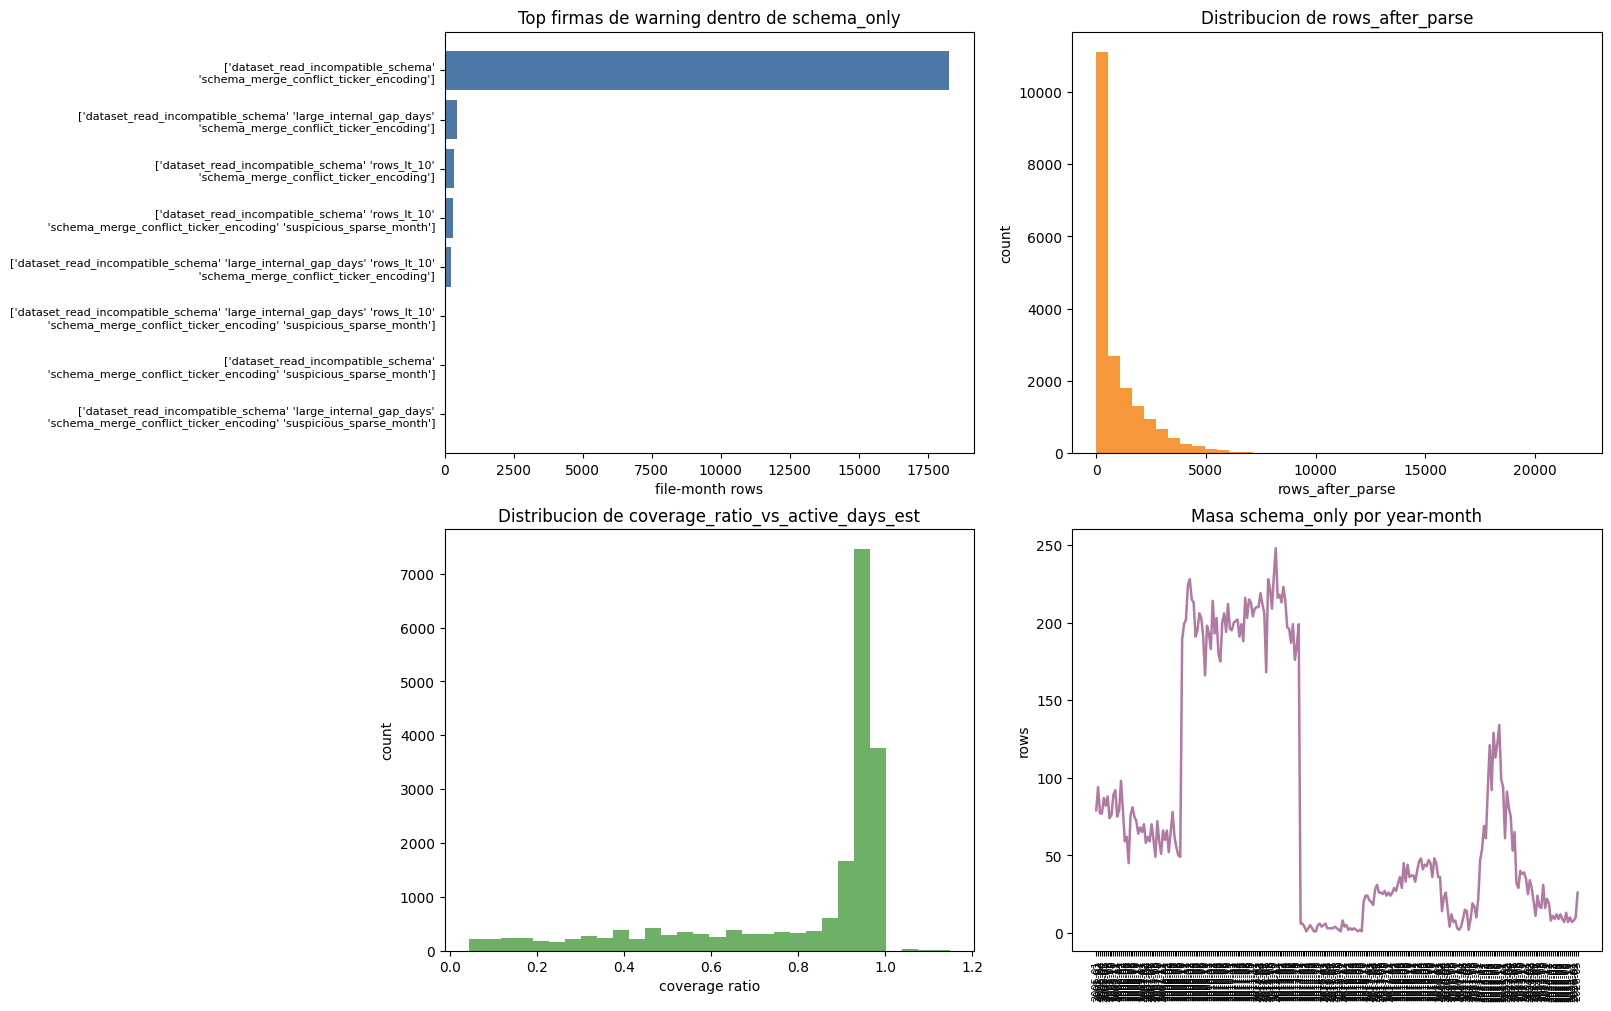

### Tablas agregadas de apoyo

,warn_signature,rows,pct_within_schema_only
1,['dataset_read_incompatible_schema'\n 'schema_...,18266,92.659666
3,['dataset_read_incompatible_schema' 'large_int...,453,2.297976
7,['dataset_read_incompatible_schema' 'rows_lt_1...,332,1.684168
6,['dataset_read_incompatible_schema' 'rows_lt_1...,313,1.587785
5,['dataset_read_incompatible_schema' 'large_int...,235,1.192107
4,['dataset_read_incompatible_schema' 'large_int...,59,0.299295
0,['dataset_read_incompatible_schema'\n 'schema_...,54,0.273931
2,['dataset_read_incompatible_schema' 'large_int...,1,0.005073


,ticker,rows
564,HVT.A,154
511,GTN.A,116
77,ARL,106
1192,UBP,105
261,CRD.A,104
1122,TCI,104
226,CIX,104
1034,SCX,103
775,MTR,102
649,KFS,100


,rows_after_parse,active_days,max_gap_days,coverage_ratio,vw_rows
count,19713.000000,19713.000000,19713.000000,19713.000000,19713.0
mean,935.188150,17.600771,4.451073,0.810382,0.0
std,1259.623441,5.571253,2.471069,0.253329,0.0
min,1.000000,1.000000,0.000000,0.043478,0.0
25%,70.000000,16.000000,3.000000,0.727273,0.0
50%,376.000000,20.000000,4.000000,0.952381,0.0
75%,1365.000000,21.000000,4.000000,0.956522,0.0
max,21943.000000,26.000000,28.000000,1.150000,0.0


In [5]:
warn_counts = SCHEMA.groupby('warn_signature', dropna=False).size().reset_index(name='rows').sort_values('rows', ascending=False)
warn_counts['pct_within_schema_only'] = 100.0 * warn_counts['rows'] / max(len(SCHEMA), 1)
ticker_counts = SCHEMA.groupby('ticker', dropna=False).size().reset_index(name='rows').sort_values('rows', ascending=False).head(20)
ym_counts = SCHEMA.groupby('ym', dropna=False).size().reset_index(name='rows').sort_values('ym')

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
top_warn = warn_counts.head(8).copy()
axes[0,0].barh(top_warn['warn_signature'][::-1], top_warn['rows'][::-1], color='#4c78a8')
axes[0,0].set_title('Top firmas de warning dentro de schema_only')
axes[0,0].set_xlabel('file-month rows')
axes[0,0].tick_params(axis='y', labelsize=8)
axes[0,1].hist(SCHEMA['rows_after_parse'].dropna(), bins=40, color='#f58518', alpha=0.85)
axes[0,1].set_title('Distribucion de rows_after_parse')
axes[0,1].set_xlabel('rows_after_parse')
axes[0,1].set_ylabel('count')
axes[1,0].hist(SCHEMA['coverage_ratio'].dropna(), bins=30, color='#54a24b', alpha=0.85)
axes[1,0].set_title('Distribucion de coverage_ratio_vs_active_days_est')
axes[1,0].set_xlabel('coverage ratio')
axes[1,0].set_ylabel('count')
axes[1,1].plot(ym_counts['ym'], ym_counts['rows'], color='#b279a2', linewidth=1.8)
axes[1,1].set_title('Masa schema_only por year-month')
axes[1,1].set_ylabel('rows')
axes[1,1].tick_params(axis='x', labelrotation=90, labelsize=7)
plt.show()

display(Markdown('### Tablas agregadas de apoyo'))
display(warn_counts.head(12))
display(ticker_counts)
display(SCHEMA[['rows_after_parse','active_days','max_gap_days','coverage_ratio','vw_rows']].describe())

## 2. Lectura analitica de las visualizaciones

### Firmas de warning

- si domina casi por completo la pareja `dataset_read_incompatible_schema` + `schema_merge_conflict_ticker_encoding`, el problema central es de compatibilidad de lectura y merge de schema.

### Rows after parse

- esta distribucion muestra que el bloque no es simplemente `empty noise`; hay meses con muy poca masa, pero tambien muchos meses con contenido amplio.

### Coverage ratio

- si la mediana de cobertura sigue siendo alta, el problema no es que el archivo este vacio, sino que su lectura agregada como dataset choca por schema.

### Serie temporal por month

- sirve para ver si es una anomalia puntual o una familia persistente de archivos estructuralmente legibles pero con conflicto de schema.


In [6]:
def _show_case(row):
    display(Markdown('### Metadatos del caso'))
    cols = [c for c in ['ticker','year','month','quality_policy','operational_decision','rows_after_parse','active_days','max_gap_days','coverage_ratio','vw_rows','warn_signature','dataset_read_error_clean','file'] if c in row.index]
    display(pd.DataFrame([row[cols].to_dict()]))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    vals = [row.get('rows_after_parse', np.nan), row.get('active_days', np.nan), row.get('coverage_ratio', np.nan)]
    labels = ['rows_after_parse', 'active_days', 'coverage_ratio']
    colors = ['#f58518', '#54a24b', '#4c78a8']
    axes[0].bar(labels, vals, color=colors)
    axes[0].set_title('Magnitud basica del file-month')
    axes[1].bar(['vw_rows','max_gap_days'], [row.get('vw_rows', np.nan), row.get('max_gap_days', np.nan)], color=['#e45756','#72b7b2'])
    axes[1].set_title('Por que no cae en bloque VW')
    axes[2].axis('off')
    txt = '\n'.join([
        f"ticker={row.get('ticker')}",
        f"year_month={int(row.get('year')):04d}-{int(row.get('month')):02d}",
        f"policy={row.get('quality_policy', 'good')}",
        f"operational={row.get('operational_decision')}",
        f"warns={row.get('warn_signature')}",
    ])
    axes[2].text(0.01, 0.95, txt, va='top', ha='left', fontsize=10, family='monospace')
    axes[2].set_title('Leyenda del caso')
    plt.show()
    display(Markdown('### Lectura tecnica'))
    display(Markdown('- Este caso no cae en `schema_plus_vw` porque la firma dominante es estructural y `vw_rows` no es la razon de clasificacion.'))
    display(Markdown('- El error de lectura agregado muestra conflicto de tipos al intentar materializar el dataset como un todo; no describe una corrupcion economica del precio por si misma.'))

signature_dd = widgets.Dropdown(description='firma', layout=widgets.Layout(width='560px'))
ticker_dd = widgets.Dropdown(description='ticker', layout=widgets.Layout(width='280px'))
ym_dd = widgets.Dropdown(description='year-month', layout=widgets.Layout(width='220px'))
out = widgets.Output()

def _filtered():
    df = SCHEMA.copy()
    if signature_dd.value not in (None, 'ALL'):
        df = df[df['warn_signature'].eq(signature_dd.value)]
    if ticker_dd.value not in (None, 'ALL'):
        df = df[df['ticker'].eq(ticker_dd.value)]
    return df.sort_values(['ticker','year','month']).reset_index(drop=True)

def _refresh_tickers(*args):
    df = SCHEMA.copy()
    if signature_dd.value not in (None, 'ALL'):
        df = df[df['warn_signature'].eq(signature_dd.value)]
    tickers = ['ALL'] + sorted(df['ticker'].dropna().unique().tolist())
    ticker_dd.options = tickers
    ticker_dd.value = tickers[0] if tickers else None

def _refresh_months(*args):
    df = _filtered()
    opts = []
    for _, row in df.iterrows():
        label = f"{row['ym']} | rows={int(row['rows_after_parse']) if pd.notna(row['rows_after_parse']) else 'NA'} | gap={int(row['max_gap_days']) if pd.notna(row['max_gap_days']) else 'NA'}"
        opts.append((label, int(row.name)))
    ym_dd.options = opts
    ym_dd.value = opts[0][1] if opts else None

def _render(*args):
    with out:
        clear_output(wait=True)
        df = _filtered()
        if ym_dd.value is None or df.empty:
            display(Markdown('**Sin casos para la seleccion actual.**'))
            return
        row = df.loc[ym_dd.value]
        _show_case(row)

signature_dd.options = ['ALL'] + sorted(SCHEMA['warn_signature'].dropna().unique().tolist())
signature_dd.value = 'ALL'
signature_dd.observe(_refresh_tickers, names='value')
signature_dd.observe(lambda change: _refresh_months(), names='value')
signature_dd.observe(_render, names='value')
ticker_dd.observe(_refresh_months, names='value')
ticker_dd.observe(_render, names='value')
ym_dd.observe(_render, names='value')
_refresh_tickers()
_refresh_months()
display(widgets.VBox([
    widgets.HTML('<h2>3. Selector interactivo de casos schema_only</h2>'),
    widgets.HBox([signature_dd, ticker_dd, ym_dd]),
    out,
]))
_render()

## 3. Como usar el selector

### Que permite seleccionar

- una firma de warning;
- un ticker concreto;
- y cualquier `year-month` de ese subconjunto.

### Que responde

- si el caso es realmente `schema_only`;
- si la anomalia dominante es la misma que en el resto de la masa;
- y si el archivo conserva volumen, cobertura y actividad suficientes para que la lectura correcta sea `good` pese al conflicto de schema agregado.


## 4. Veredicto institucional

La lectura correcta del `5.89%` queda asi:

- no es una cola economica dominada por `vw`;
- es un bloque mayoritariamente homogeneo de incompatibilidad de lectura / merge de schema;
- por eso historicamente se trato como `RESCUE_SCHEMA_ONLY -> good`;
- y este notebook deja al inspector la capacidad de comprobarlo agregado y caso por caso.
